In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from pathlib import Path

DATA_DIR = Path("/content/drive/MyDrive/Colab Notebooks/Projects/fraud_detection/data")
RANDOM_STATE = 42
CUTOFF_DATE = "2018-09-01"


In [3]:
import pandas as pd

NEEDED_COLS = [
    'TX_DATETIME','CUSTOMER_ID','TERMINAL_ID',
    'TX_AMOUNT','TX_FRAUD'
]

def load_data(path):
    files = sorted(path.glob("*.pkl"))

    df = pd.concat(
        (pd.read_pickle(f)[NEEDED_COLS] for f in files),
        ignore_index=True
    )

    # memory optimization
    df['TX_AMOUNT'] = df['TX_AMOUNT'].astype('float32')
    df['TX_FRAUD'] = df['TX_FRAUD'].astype('int8')
    df['CUSTOMER_ID'] = df['CUSTOMER_ID'].astype('int32')
    df['TERMINAL_ID'] = df['TERMINAL_ID'].astype('int32')

    df['TX_DATETIME'] = pd.to_datetime(df['TX_DATETIME'])

    return df

full_df = load_data(DATA_DIR)


In [4]:
def create_time_features(df):
    df = df.sort_values('TX_DATETIME')

    df['TX_HOUR'] = df['TX_DATETIME'].dt.hour
    df['TX_DAY_OF_WEEK'] = df['TX_DATETIME'].dt.dayofweek

    return df

full_df = create_time_features(full_df)


In [5]:
def add_customer_behavior_features(df):
    # Sort and ensure unique index for safe assignment
    df = df.sort_values(['CUSTOMER_ID', 'TX_DATETIME']).reset_index(drop=True)

    # Use groupby rolling and explicitly extract values to avoid index alignment issues
    # Note: we use values to bypass the index check if we are certain of order
    rolling_group = df.groupby('CUSTOMER_ID').rolling('24h', on='TX_DATETIME')

    df['CUST_AVG_AMOUNT_24h'] = rolling_group['TX_AMOUNT'].mean().values
    df['CUST_TX_COUNT_24h'] = rolling_group['TX_AMOUNT'].count().values

    return df

full_df = add_customer_behavior_features(full_df)

In [6]:
# ---------------------------------------------------
# TERMINAL (MERCHANT) RISK FEATURES
# ---------------------------------------------------

def add_terminal_risk_features(df):

    df = df.sort_values(['TERMINAL_ID', 'TX_DATETIME']).reset_index(drop=True)

    # rolling 7-day window per terminal
    terminal_group = df.groupby('TERMINAL_ID').rolling('7d', on='TX_DATETIME')

    # number of transactions at terminal
    df['TERM_TX_COUNT_7d'] = terminal_group['TX_AMOUNT'].count().values

    # fraud rate at terminal
    df['TERM_FRAUD_RATE_7d'] = terminal_group['TX_FRAUD'].mean().fillna(0).values

    return df

full_df = add_terminal_risk_features(full_df)


In [7]:
cutoff = pd.Timestamp(CUTOFF_DATE)

train_df = full_df[full_df.TX_DATETIME < cutoff]
test_df  = full_df[full_df.TX_DATETIME >= cutoff]


In [8]:
FEATURES = [
 'TX_HOUR',
 'TX_DAY_OF_WEEK',
 'TX_AMOUNT',
 'CUST_AVG_AMOUNT_24h',
 'CUST_TX_COUNT_24h',
 'TERM_TX_COUNT_7d',
 'TERM_FRAUD_RATE_7d'
]


TARGET = 'TX_FRAUD'

X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_test = test_df[FEATURES]
y_test = test_df[TARGET]


In [9]:
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="aucpr",
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='aucpr',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [10]:
from sklearn.metrics import average_precision_score

probs = pipeline.predict_proba(X_test)[:,1]

pr_auc = average_precision_score(y_test, probs)
print("PR-AUC:", pr_auc)


PR-AUC: 0.9351011783431414


In [11]:
import numpy as np
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, probs)

f1 = 2*(precision*recall)/(precision+recall+1e-9)
best_threshold = thresholds[np.argmax(f1)]

print("Best Threshold:", best_threshold)


Best Threshold: 0.899379


In [12]:
from sklearn.metrics import classification_report, confusion_matrix

# convert probability to class using optimal threshold
y_pred = (probs >= best_threshold).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))


[[285082    244]
 [   444   2103]]
              precision    recall  f1-score   support

           0     0.9984    0.9991    0.9988    285326
           1     0.8960    0.8257    0.8594      2547

    accuracy                         0.9976    287873
   macro avg     0.9472    0.9124    0.9291    287873
weighted avg     0.9975    0.9976    0.9976    287873



In [13]:
# -------------------------------------------------------
# FINANCIAL IMPACT EVALUATION
# -------------------------------------------------------

test_eval = test_df.copy()

# attach predictions
test_eval['pred'] = y_pred
test_eval['proba'] = probs

# ------------------------------
# Fraud caught (True Positives)
# ------------------------------
fraud_caught = test_eval[
    (test_eval.TX_FRAUD == 1) & (test_eval.pred == 1)
]['TX_AMOUNT'].sum()

# ------------------------------
# Fraud missed (False Negatives)
# ------------------------------
fraud_missed = test_eval[
    (test_eval.TX_FRAUD == 1) & (test_eval.pred == 0)
]['TX_AMOUNT'].sum()

# ------------------------------
# False alarms (False Positives)
# ------------------------------
false_alarms = test_eval[
    (test_eval.TX_FRAUD == 0) & (test_eval.pred == 1)
].shape[0]

# ------------------------------
# Genuine transactions allowed
# ------------------------------
genuine_allowed = test_eval[
    (test_eval.TX_FRAUD == 0) & (test_eval.pred == 0)
].shape[0]

print("========= BUSINESS METRICS =========")
print(f"Fraud money prevented (₹): {fraud_caught:,.2f}")
print(f"Fraud money lost (₹): {fraud_missed:,.2f}")
print(f"False alarms (customers blocked): {false_alarms}")
print(f"Genuine transactions allowed: {genuine_allowed}")


========= BUSINESS METRICS =========
Fraud money prevented (₹): 294,133.38
Fraud money lost (₹): 35,747.35
False alarms (customers blocked): 244
Genuine transactions allowed: 285082


In [14]:
total_fraud = test_eval[test_eval.TX_FRAUD == 1]['TX_AMOUNT'].sum()
recovery_rate = fraud_caught / total_fraud

print(f"Fraud Recovery Rate: {recovery_rate*100:.2f}%")


Fraud Recovery Rate: 89.16%


In [15]:
# -------------------------------
# RISK DECISION ENGINE
# -------------------------------

def risk_action(p):
    if p >= 0.85:
        return "BLOCK_CARD"
    elif p >= 0.65:
        return "SEND_OTP"
    else:
        return "ALLOW"

test_eval['ACTION'] = test_eval['proba'].apply(risk_action)

test_eval['ACTION'].value_counts()


,count
ACTION,
ALLOW,284681
BLOCK_CARD,2519
SEND_OTP,673


In [16]:
# frauds caught by block
blocked_fraud = test_eval[
    (test_eval.ACTION == "BLOCK_CARD") & (test_eval.TX_FRAUD == 1)
].shape[0]

# frauds verified by otp
otp_fraud = test_eval[
    (test_eval.ACTION == "SEND_OTP") & (test_eval.TX_FRAUD == 1)
].shape[0]

# genuine customers bothered
otp_customers = test_eval[
    (test_eval.ACTION == "SEND_OTP") & (test_eval.TX_FRAUD == 0)
].shape[0]

print("Frauds auto-blocked:", blocked_fraud)
print("Frauds sent to OTP:", otp_fraud)
print("Legitimate customers asked OTP:", otp_customers)


Frauds auto-blocked: 2168
Frauds sent to OTP: 144
Legitimate customers asked OTP: 529


In [17]:
# ----------------------------------------
# TOP 1% REVIEW SIMULATION
# ----------------------------------------

# sort transactions by fraud probability
review_df = test_eval.sort_values('proba', ascending=False)

# bank can only investigate top 1%
top_k = int(len(review_df) * 0.01)

top_review = review_df.head(top_k)

# fraud captured in reviewed transactions
fraud_captured_top1 = top_review['TX_FRAUD'].sum()

total_fraud_transactions = test_eval['TX_FRAUD'].sum()

recall_at_1 = fraud_captured_top1 / total_fraud_transactions

print("Transactions reviewed:", top_k)
print("Frauds found in review:", fraud_captured_top1)
print("Recall @ Top 1%:", recall_at_1*100, "%")


Transactions reviewed: 2878
Frauds found in review: 2261
Recall @ Top 1%: 88.77110325873578 %


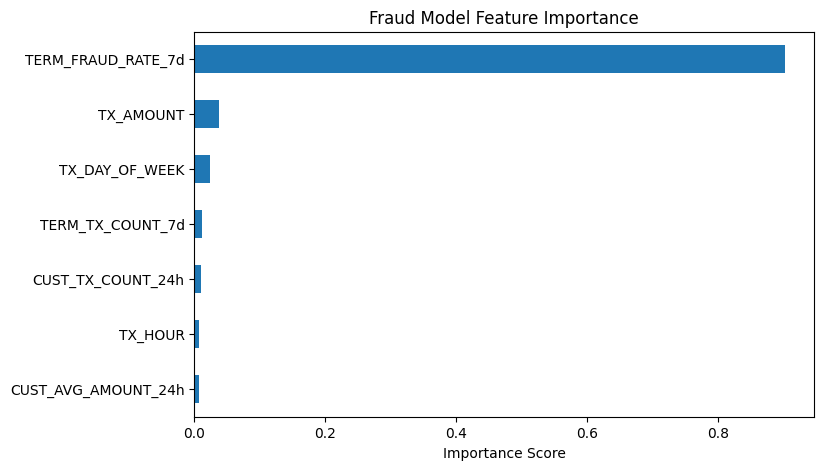

,0
CUST_AVG_AMOUNT_24h,0.006548
TX_HOUR,0.007423
CUST_TX_COUNT_24h,0.009623
TERM_TX_COUNT_7d,0.011770
TX_DAY_OF_WEEK,0.024078
TX_AMOUNT,0.038069
TERM_FRAUD_RATE_7d,0.902488


In [18]:
import matplotlib.pyplot as plt
import pandas as pd

model = pipeline.named_steps['model']

importance = pd.Series(model.feature_importances_, index=FEATURES)
importance = importance.sort_values()

plt.figure(figsize=(8,5))
importance.plot(kind='barh')
plt.title("Fraud Model Feature Importance")
plt.xlabel("Importance Score")
plt.show()

importance
